In [2]:
import numpy as np
import cv2 as cv

from matplotlib import pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense

In [11]:
img = cv.imread("mario.png", cv.IMREAD_GRAYSCALE)
img.shape

(180, 140)

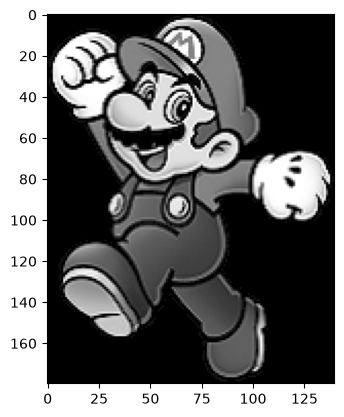

In [34]:
plt.imshow(img, cmap="gray")

In [24]:
X = np.expand_dims(img, 2)
X = np.expand_dims(X, 0).astype(np.float32)
X.shape

(1, 180, 140, 1)

In [25]:
conv = Conv2D(4, (5, 5), activation="relu", input_shape=(180, 140, 1))
pool = MaxPool2D(pool_size=(2, 2))

conv.output

In [55]:
out_1 = conv(X)
output = pool(out_1)

TensorShape([1, 88, 68, 4])

In [64]:
out_1 = np.transpose(out_1, (3, 1, 2, 0))
out_1 = np.squeeze(out_1)
out_1.shape

(4, 176, 136)

In [56]:
output = np.transpose(output, (3, 1, 2, 0))
output = np.squeeze(output)
output.shape

(4, 88, 68)

In [41]:
weights, bias = conv.weights
weights = np.transpose(weights, (3, 0, 1, 2))
weights = np.squeeze(weights)
weights.shape

(4, 5, 5)

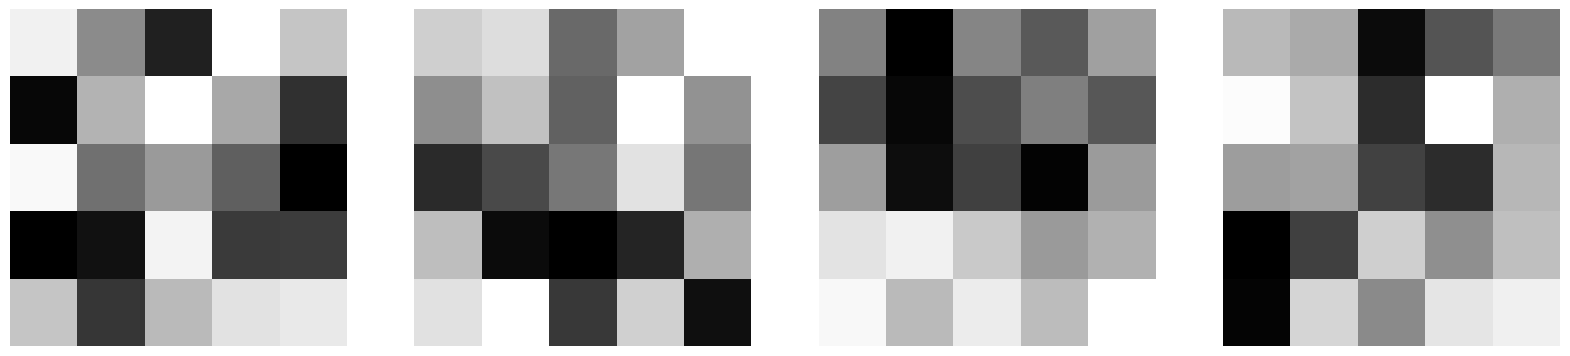

In [42]:
fig, axes = plt.subplots(1,4,figsize=(20,10))

for idx, ax in enumerate(axes.ravel()):
    ax.imshow(weights[idx], cmap="gray")
    ax.set_axis_off()


In [65]:
out_1.shape, output.shape

((4, 176, 136), (4, 88, 68))

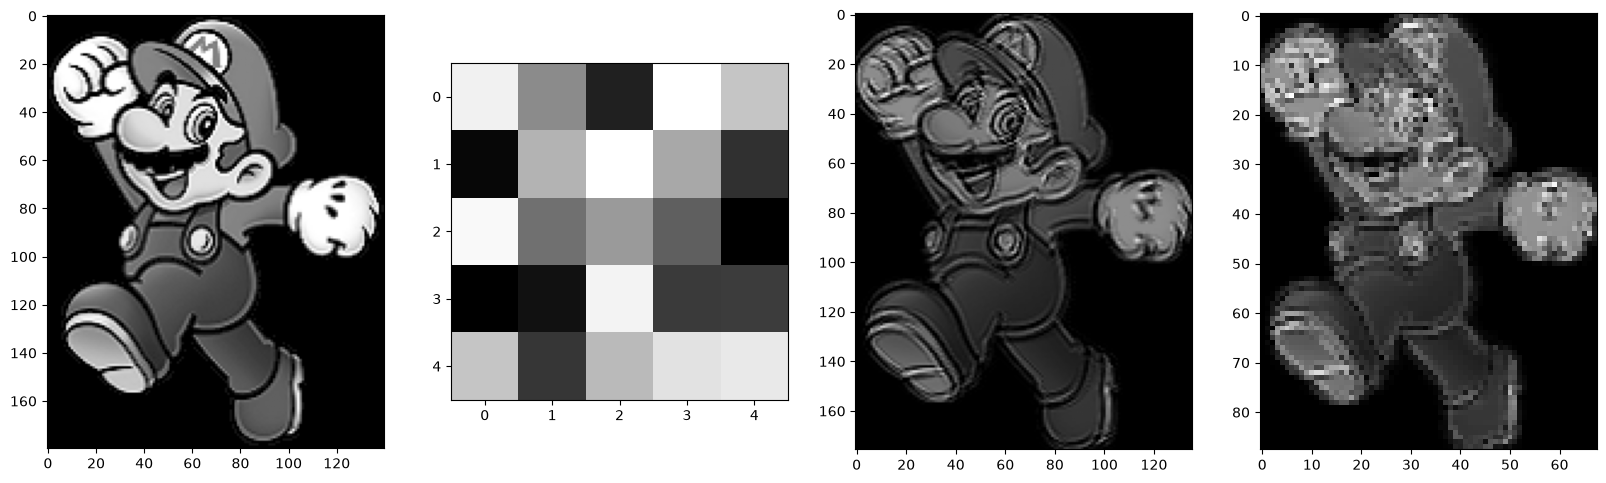

In [68]:
plt.figure(figsize=(20,8))

plt.subplot(141)
plt.imshow(img,cmap="gray")

plt.subplot(142)
plt.imshow(weights[0],cmap="gray")


plt.subplot(143)
plt.imshow(out_1[0,:,:],cmap="gray")

plt.subplot(144)
plt.imshow(np.clip(output[0,:,:],0,255),cmap="gray")

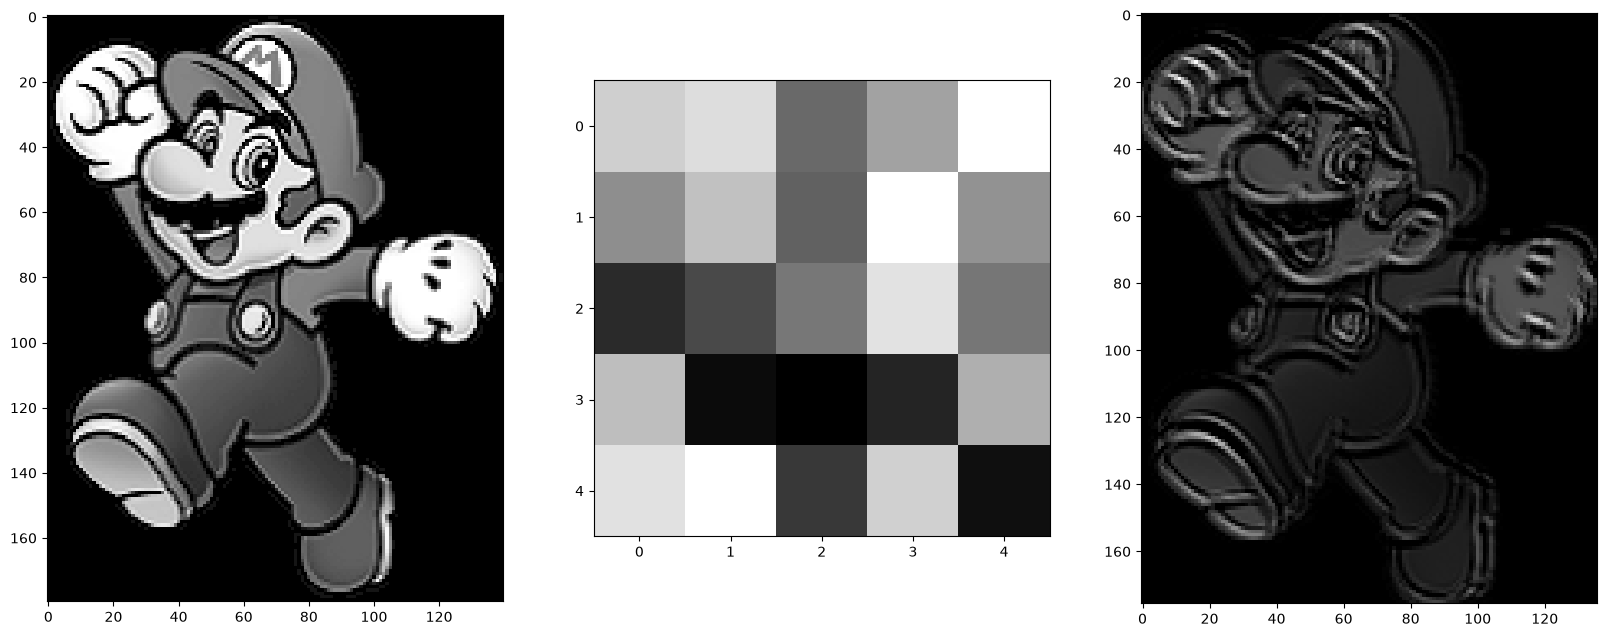

In [51]:
plt.figure(figsize=(20,8))

plt.subplot(131)
plt.imshow(img,cmap="gray")

plt.subplot(132)
plt.imshow(weights[1],cmap="gray")


plt.subplot(133)
plt.imshow(out_1[:,:,1],cmap="gray")

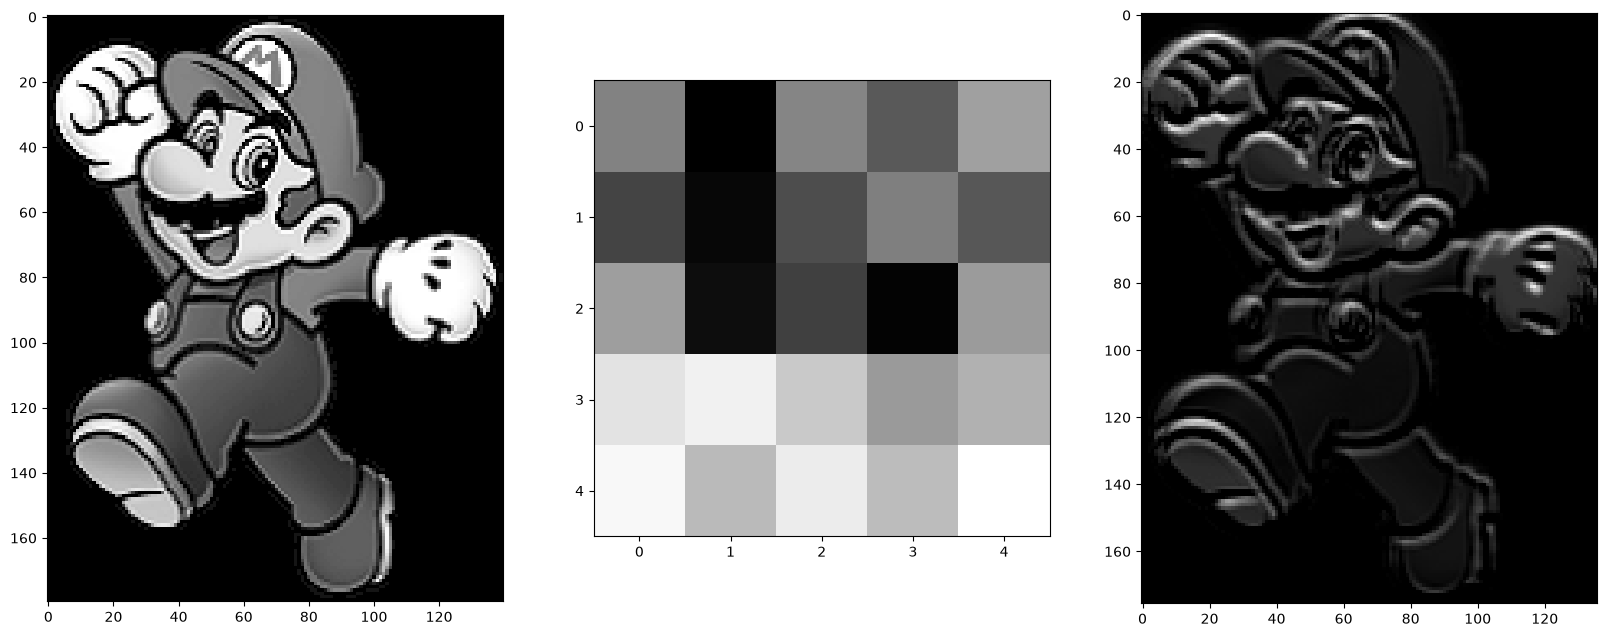

In [53]:
plt.figure(figsize=(20,8))

plt.subplot(131)
plt.imshow(img,cmap="gray")

plt.subplot(132)
plt.imshow(weights[2],cmap="gray")


plt.subplot(133)
plt.imshow(out_1[:,:,2],cmap="gray")

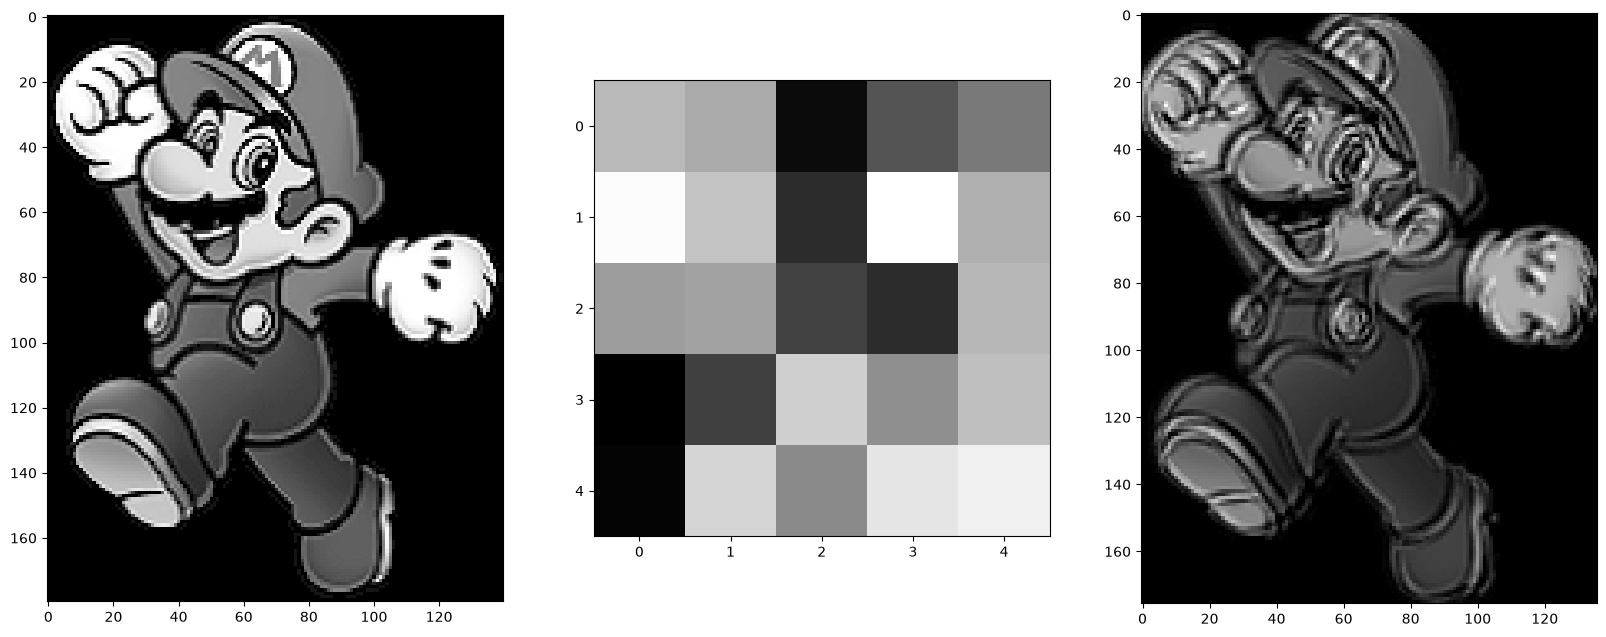

In [52]:
plt.figure(figsize=(20,8))

plt.subplot(131)
plt.imshow(img,cmap="gray")

plt.subplot(132)
plt.imshow(weights[3],cmap="gray")


plt.subplot(133)
plt.imshow(out_1[:,:,3],cmap="gray")